In [93]:
import jax 
import jax.numpy as jnp

import matplotlib.pyplot as plt

from probjax.utils.torchvision_datasets import MNIST, NumpyLoader

from probjax.distributions.divergences.wasserstein import wasserstein_distance, sliced_wasserstein_distance, max_slice_wasserstein_distance
from probjax.distributions.discrete import Empirical
from probjax.distributions.independent import Independent
from probjax.distributions import Uniform, Normal

from sklearn.manifold import MDS, Isomap, TSNE

In [2]:
def transform_data(x):
    # Uniformly quantize
    x = jnp.reshape(jnp.asarray(x, dtype=jnp.float32), (-1, 784))
    normed = x / 255.
    return normed

mnist_dataset = MNIST('/tmp/mnist/', download=True, transform=transform_data)
training_generator = NumpyLoader(mnist_dataset, batch_size=100, num_workers=0)

input_dim = 784

In [3]:

# Separate the datasets by label
datasets_per_num = [[] for _ in range(10)]
for i in range(len(mnist_dataset)):
    image, label = mnist_dataset[i]
    datasets_per_num[label].append(image)


In [4]:
samples_per_num = 5000
datasets_per_num = [jnp.squeeze(jnp.asarray(x))[:samples_per_num] for x in datasets_per_num]

In [5]:
p0 = Independent(Empirical(datasets_per_num[0]), 1)
p1 = Independent(Empirical(datasets_per_num[1]), 1)
p2 = Independent(Empirical(datasets_per_num[2]), 1)
p3 = Independent(Empirical(datasets_per_num[3]), 1)
p4 = Independent(Empirical(datasets_per_num[4]), 1)
p5 = Independent(Empirical(datasets_per_num[5]), 1)
p6 = Independent(Empirical(datasets_per_num[6]), 1)
p7 = Independent(Empirical(datasets_per_num[7]), 1)
p8 = Independent(Empirical(datasets_per_num[8]), 1)
p9 = Independent(Empirical(datasets_per_num[9]), 1)
p10 = Independent(Uniform(jnp.zeros((input_dim,)), jnp.ones((input_dim,))), 1)

distributions = [p0, p1, p2, p3, p4, p5, p6, p7, p8, p9, p10]

In [12]:
# distances_w2 = jnp.zeros((len(distributions), len(distributions)))
# key = jax.random.PRNGKey(0)
# for i in range(len(distributions)):
#     for j in range(i, len(distributions)):
#         key, subkey = jax.random.split(key)
#         distance_w2 = wasserstein_distance(distributions[i], distributions[j], mc_samples=400, key=key,  order=2., epsilon=0.1)
#         distances_w2 = distances_w2.at[i, j].set(distance_w2)
        
# # Normalize with self distance
# distances_w2 = distances_w2 - jnp.diag(distances_w2)[:, None]
# distances_w2 = jnp.triu(distances_w2) + jnp.triu(distances_w2, k=1).T

In [61]:
distances_w1 = jnp.zeros((len(distributions), len(distributions)))
key = jax.random.PRNGKey(0)
for i in range(len(distributions)):
    for j in range(i, len(distributions)):
        key, subkey = jax.random.split(key)
        distance_w1 = wasserstein_distance(distributions[i], distributions[j], mc_samples=400, key=key,  order=1., epsilon=0.1)
        distances_w1 = distances_w1.at[i, j].set(distance_w1)
        
# Normalize with self distance and symmetrize

distances_w1 = distances_w1 - jnp.diag(distances_w1)[:, None]
distances_w1 = jnp.triu(distances_w1) + jnp.triu(distances_w1, k=1).T

In [14]:
# distances_sliced_w1 = jnp.zeros((len(distributions), len(distributions)))
# key = jax.random.PRNGKey(0)
# for i in range(len(distributions)):
#     for j in range(i, len(distributions)):
#         key, subkey = jax.random.split(key)
#         distance_sliced_w1 = sliced_wasserstein_distance(distributions[i], distributions[j], mc_samples=5000, key=key,  num_slices=1000)
#         distances_sliced_w1 = distances_sliced_w1.at[i, j].set(distance_sliced_w1)
        
# # Normalize with self distance and symmetrize
# distances_sliced_w1 = distances_sliced_w1 - jnp.diag(distances_sliced_w1)[:, None]
# distances_sliced_w1 = jnp.triu(distances_sliced_w1) + jnp.triu(distances_sliced_w1, k=1).T

In [15]:
# distances_sliced_w1_more_slices = jnp.zeros((len(distributions), len(distributions)))
# key = jax.random.PRNGKey(0)
# for i in range(len(distributions)):
#     for j in range(i, len(distributions)):
#         key, subkey = jax.random.split(key)
#         distance_sliced_w1 = sliced_wasserstein_distance(distributions[i], distributions[j], mc_samples=5000, key=key,  num_slices=10000)
#         distances_sliced_w1_more_slices = distances_sliced_w1_more_slices.at[i, j].set(distance_sliced_w1)
        
# # Normalize with self distance and symmetrize
# distances_sliced_w1_more_slices = distances_sliced_w1_more_slices - jnp.diag(distances_sliced_w1_more_slices)[:, None]
# distances_sliced_w1_more_slices = jnp.triu(distances_sliced_w1_more_slices) + jnp.triu(distances_sliced_w1_more_slices, k=1).T

In [37]:
distances_sliced_w1_max_slices = jnp.zeros((len(distributions), len(distributions)))
key = jax.random.PRNGKey(0)
for i in range(len(distributions)):
    for j in range(i, len(distributions)):
        key, subkey = jax.random.split(key)
        distance_sliced_w1 = max_slice_wasserstein_distance(distributions[i], distributions[j], mc_samples=4000, key=jax.random.PRNGKey(i), tol=1e-2, num_init=10)
        distances_sliced_w1_max_slices = distances_sliced_w1_max_slices.at[i, j].set(distance_sliced_w1)
        
# Normalize with self distance and symmetrize
distances_sliced_w1_max_slices = distances_sliced_w1_max_slices - jnp.diag(distances_sliced_w1_max_slices)
distances_sliced_w1_max_slices = jnp.triu(distances_sliced_w1_max_slices) + jnp.triu(distances_sliced_w1_max_slices, k=1).T

In [64]:
#jnp.save('data/distances_w1.npy', distances_w1)
# jnp.save('data/distances_w2.npy', distances_w2)
# jnp.save('data/distances_sliced_w1.npy', distances_sliced_w1)
# jnp.save('data/distances_sliced_w1_more_slices.npy', distances_sliced_w1_more_slices)
#jnp.save('data/distances_sliced_w1_max_slices.npy', distances_sliced_w1_max_slices)


In [6]:
distances_w1 = jnp.load('data/distances_w1.npy')
distances_w2 = jnp.load('data/distances_w2.npy')
distances_sliced_w1 = jnp.load('data/distances_sliced_w1.npy')
distances_sliced_w1_more_slices = jnp.load('data/distances_sliced_w1_more_slices.npy')
distances_sliced_w1_max_slices = jnp.load('data/distances_sliced_w1_max_slices.npy')

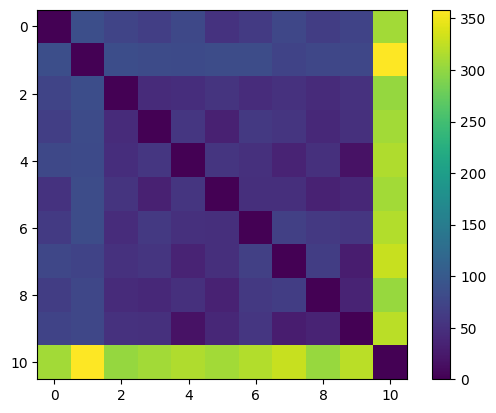

In [7]:
plt.imshow(distances_w1)
plt.colorbar()

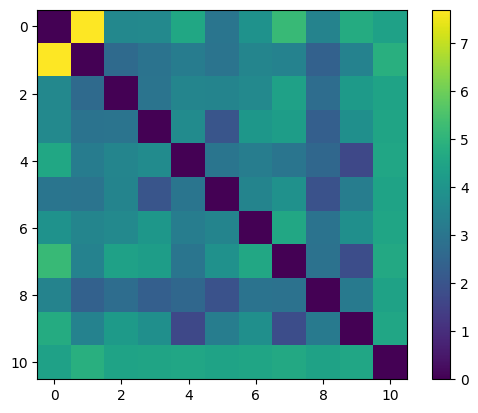

In [8]:
plt.imshow(distances_w2)
plt.colorbar()

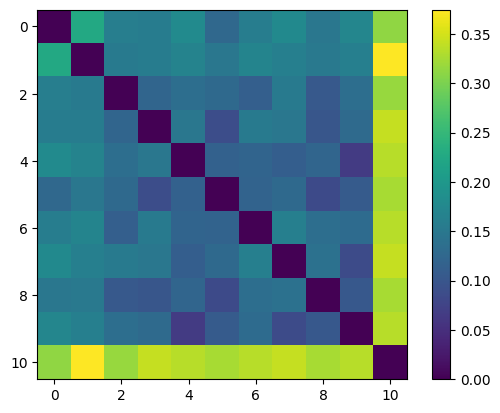

In [9]:
plt.imshow(distances_sliced_w1)
plt.colorbar()

In [10]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation


In [11]:
from probjax.distributions.divergences.wasserstein import _1d_wasserstein_without_cdf
from jax.scipy.optimize import minimize

In [12]:
mds_embedding1 = MDS(n_components=2, dissimilarity='precomputed', max_iter=50000, eps=1e-10, random_state=np.random.RandomState(0), n_init=500)
w1_embedding = mds_embedding1.fit_transform(distances_w1)
#w2_embedding = mds_embedding1.fit_transform(distances_w2)
sliced_w1_embedding = mds_embedding1.fit_transform(distances_sliced_w1)
sliced_w1_embedding_more_slices = mds_embedding1.fit_transform(distances_sliced_w1_more_slices)
max_sliced_w1_embedding = mds_embedding1.fit_transform(distances_sliced_w1_max_slices)

/root/miniconda3/envs/probjax/lib/python3.10/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/root/miniconda3/envs/probjax/lib/python3.10/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/root/miniconda3/envs/probjax/lib/python3.10/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/root/miniconda3/envs/probjax/lib/python3.10/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in ver

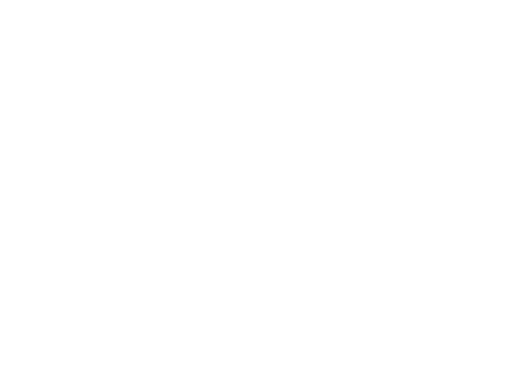

In [207]:
# mds_embedding1 = Isomap(n_components=2)
# w1_embedding = mds_embedding1.fit_transform(distances_w1)
# w2_embedding = mds_embedding1.fit_transform(distances_w2)
# sliced_w1_embedding = mds_embedding1.fit_transform(distances_sliced_w1)
# sliced_w1_embedding_more_slices = mds_embedding1.fit_transform(distances_sliced_w1_more_slices)

In [13]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.linalg import orthogonal_procrustes

def procrustes_alignment(embeddings_list):
    # Convert the list of embeddings to NumPy array
    embeddings_array = np.array(embeddings_list)

    # Get the number of embeddings and the dimensionality of each embedding
    num_embeddings, embedding_dim = embeddings_array.shape[:2]

    # Compute pairwise distances between embeddings
    pairwise_distances = cdist(embeddings_array[0], embeddings_array[1], 'euclidean')

    # Perform Procrustes alignment for each pair of embeddings
    aligned_embedding = embeddings_array[0]
    aligned_embedding = aligned_embedding - np.mean(aligned_embedding, axis=0, keepdims=True)
    aligned_embedding = aligned_embedding / np.std(aligned_embedding, axis=0, keepdims=True)
    aligned_embeddings = [aligned_embedding]

    for i in range(1, num_embeddings):
        aligned_embedding = embeddings_array[i]
        aligned_embedding = aligned_embedding - np.mean(aligned_embedding, axis=0, keepdims=True)
        aligned_embedding = aligned_embedding / np.std(aligned_embedding, axis=0, keepdims=True)
        transformation,_ = orthogonal_procrustes(embeddings_array[0],aligned_embedding)

        # Apply the transformation to align the current set of embeddings
        aligned_embedding = np.dot(aligned_embedding, transformation)
        # Normalize the aligned embedding to have unit norm
        
        aligned_embeddings.append(aligned_embedding)

    return aligned_embeddings

In [14]:
w1_embeddign_aligned, sliced_w1_embedding_aligned, sliced_w1_embedding_more_slices_aligned, max_sliced_w1_embedding_aligned = procrustes_alignment([w1_embedding, sliced_w1_embedding, sliced_w1_embedding_more_slices, max_sliced_w1_embedding])

#sliced_w1_embedding_more_slices_aligned, sliced_w1_embedding_aligned = procrustes_alignment([sliced_w1_embedding_more_slices_aligned, sliced_w1_embedding_aligned])

MovieWriter imagemagick unavailable; using Pillow instead.


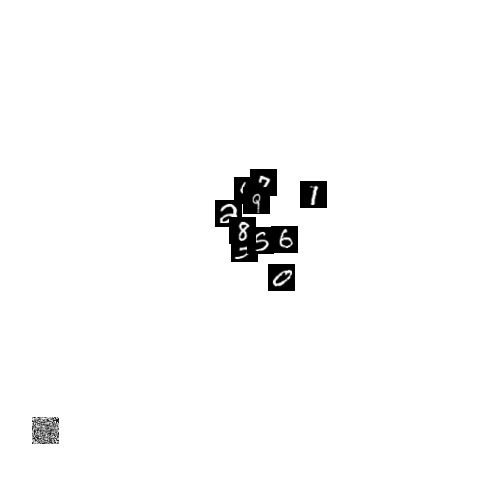

In [91]:
%matplotlib inline

# Function to update the plot for each frame
def update(frame):
    ax.clear()
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])
    for i, (x, y) in enumerate(w1_embeddign_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(frame + 1), (1,))
        ax.imshow(np.reshape(samples, (28, 28)), extent=[x-0.2, x+0.2, y-0.2, y+0.2], cmap='gray',  aspect='auto', zorder=0.1)
    plt.axis('off')
    
def init():
    ax.set_xlim([-0.75, 0.75])
    ax.set_ylim([-0.75, 0.75])
    for i, (x, y) in enumerate(w1_embeddign_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(0), (1,))
        ax.imshow(np.reshape(samples, (28, 28)), extent=[x-0.2, x+0.2, y-0.2, y+0.2], cmap='gray',  aspect='auto', zorder=0.1)
    plt.axis('off')

# Create the figure and axis
fig, ax = plt.subplots(figsize=(6, 6))
plt.axis('off')

# # Create the animation
ani = animation.FuncAnimation(fig, update, frames=300, interval=500, init_func=init, blit=False, repeat=True)
ani.save('figures/w1_mnist.gif', writer='imagemagick', fps=4)
plt.show()


In [15]:
plt.savefig('figures/w1_mnist.png', dpi=300)

<Figure size 640x480 with 0 Axes>

MovieWriter imagemagick unavailable; using Pillow instead.


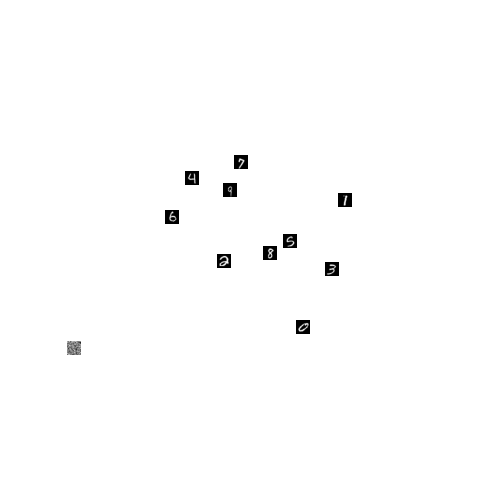

In [19]:
%matplotlib inline

# Function to update the plot for each frame
def update(frame):
    ax.clear()
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])
    for i, (x, y) in enumerate(sliced_w1_embedding_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(frame + 1), (1,))
        ax.imshow(np.reshape(samples, (28, 28)), extent=[x-0.1, x+0.1, y-0.1, y+0.1], cmap='gray',  aspect='auto', zorder=0.1)
    plt.axis('off')
    
def init():
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])
    for i, (x, y) in enumerate(sliced_w1_embedding_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(0), (1,))
        ax.imshow(np.reshape(samples, (28, 28)), extent=[x-0.1, x+0.1, y-0.1, y+0.1], cmap='gray',  aspect='auto', zorder=0.1)
    plt.axis('off')

# Create the figure and axis
fig, ax = plt.subplots(figsize=(6, 6))
plt.axis('off')

# # Create the animation
ani = animation.FuncAnimation(fig, update, frames=300, interval=500, init_func=init, blit=False, repeat=True)
ani.save('figures/w1_sliced.gif', writer='imagemagick', fps=4)
plt.show()


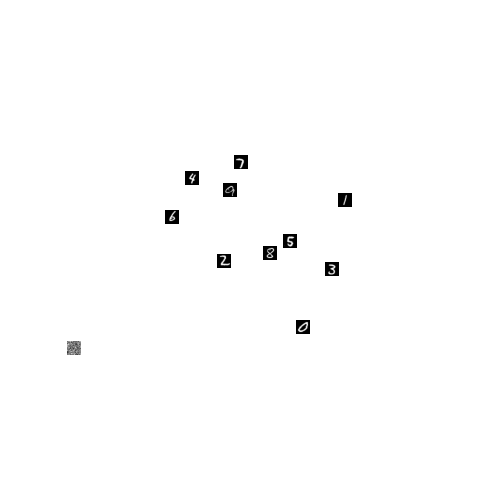

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))
update(1)
plt.savefig('figures/w1_mnist.png', dpi=300)

MovieWriter imagemagick unavailable; using Pillow instead.


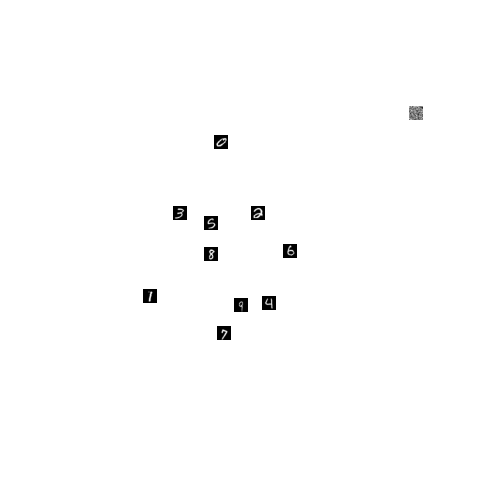

In [21]:
%matplotlib inline

# Function to update the plot for each frame
def update(frame):
    ax.clear()
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])
    for i, (x, y) in enumerate(sliced_w1_embedding_more_slices_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(frame + 1), (1,))
        ax.imshow(np.reshape(samples, (28, 28)), extent=[x-0.1, x+0.1, y-0.1, y+0.1], cmap='gray',  aspect='auto', zorder=0.1)
    plt.axis('off')
    
def init():
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])
    for i, (x, y) in enumerate(sliced_w1_embedding_more_slices_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(0), (1,))
        ax.imshow(np.reshape(samples, (28, 28)), extent=[x-0.1, x+0.1, y-0.1, y+0.1], cmap='gray',  aspect='auto', zorder=0.1)
    plt.axis('off')

# Create the figure and axis
fig, ax = plt.subplots(figsize=(6, 6))
plt.axis('off')

# # Create the animation
ani = animation.FuncAnimation(fig, update, frames=300, interval=500, init_func=init, blit=False, repeat=True)
ani.save('figures/w1_sliced_more_slices.gif', writer='imagemagick', fps=4)
plt.show()


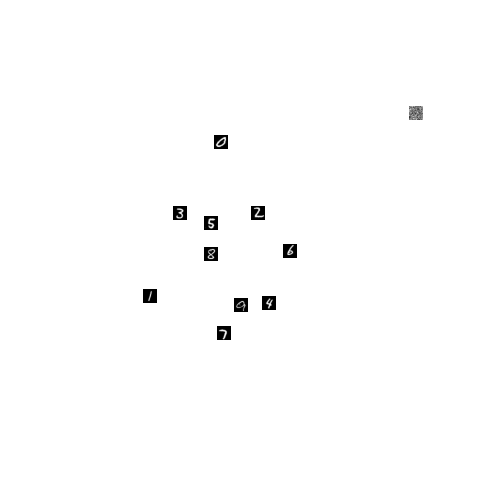

In [22]:
fig, ax = plt.subplots(figsize=(6, 6))
update(1)
plt.savefig('figures/w1_sliced_more_slices.png', dpi=300)

MovieWriter imagemagick unavailable; using Pillow instead.


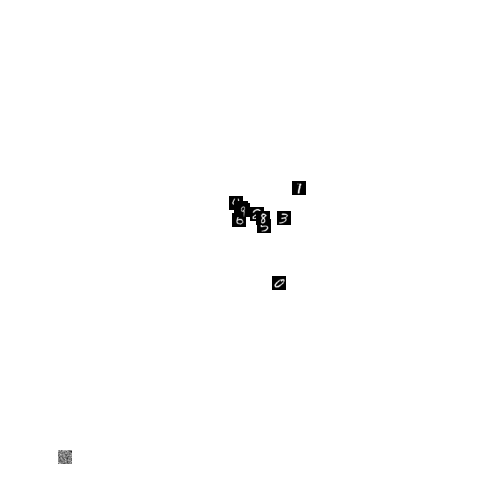

In [33]:
%matplotlib inline

# Function to update the plot for each frame
def update(frame):
    ax.clear()
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])
    for i, (x, y) in enumerate(max_sliced_w1_embedding_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(frame + 1), (1,))
        ax.imshow(np.reshape(samples, (28, 28)), extent=[x-0.1, x+0.1, y-0.1, y+0.1], cmap='gray',  aspect='auto', zorder=0.1)
    plt.axis('off')
    
def init():
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])
    for i, (x, y) in enumerate(max_sliced_w1_embedding_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(0), (1,))
        ax.imshow(1-np.reshape(samples, (28, 28)), extent=[x-0.1, x+0.1, y-0.1, y+0.1], cmap='gray',  aspect='auto', zorder=0.1)
    plt.axis('off')

# Create the figure and axis
fig, ax = plt.subplots(figsize=(6, 6))
plt.axis('off')

# # Create the animation
ani = animation.FuncAnimation(fig, update, frames=300, interval=500, init_func=init, blit=False, repeat=True)
ani.save('figures/w1_sliced_max_slices.gif', writer='imagemagick', fps=4)
plt.show()


In [50]:
import copy
def init():
    my_cmap = copy.copy(plt.cm.get_cmap('gray')) # get a copy of the gray color map
    my_cmap.set_bad(alpha=0) # set how the colormap handles 'bad' values
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])
    for i, (x, y) in enumerate(max_sliced_w1_embedding_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(1), (1,))
        samples = np.array(samples)
        samples[samples ==0] = np.nan
        ax.imshow(1-np.reshape(samples, (28, 28)), extent=[x-0.2, x+0.2, y-0.2, y+0.2], cmap=my_cmap,  aspect='auto', zorder=0.1)
    plt.axis('off')

In [56]:
from scoresbibm.src.utils.plot import use_style

/tmp/ipykernel_18469/929023461.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  my_cmap = copy.copy(plt.cm.get_cmap('gray')) # get a copy of the gray color map


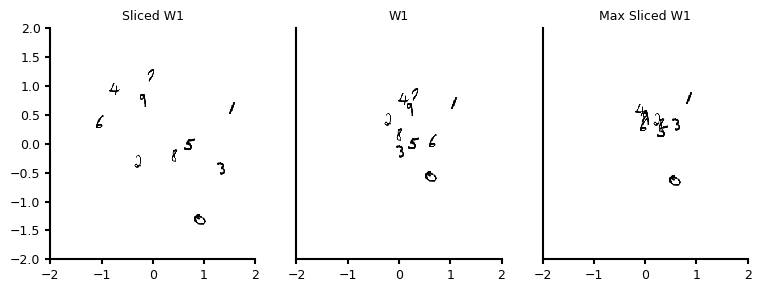

In [84]:
with use_style("pyloric"):
    fig, axes = plt.subplots(1,3,figsize=(9, 3))
    axes[0].set_title('Sliced W1')
    axes[1].set_title('W1')
    axes[2].set_title('Max Sliced W1')
    ax = axes[0]
    my_cmap = copy.copy(plt.cm.get_cmap('gray')) # get a copy of the gray color map
    my_cmap.set_bad(alpha=0) # set how the colormap handles 'bad' values
    ax.set_xlim([-2., 2.])
    ax.set_ylim([-2., 2.])
    for i, (x, y) in enumerate(sliced_w1_embedding_aligned):
        if x > -1. and x < 1. and y > -1. and y < 1.:   
            p = distributions[i] 
            samples = p.sample(jax.random.PRNGKey(1), (1,))
            samples = np.array(samples)
            samples[samples ==0] = np.nan
            ax.imshow(1-np.reshape(samples, (28, 28)), extent=[x-0.15, x+0.15, y-0.15, y+0.15], cmap=my_cmap,  aspect='auto', zorder=0.1)
        else:
            p = distributions[i]
            samples = p.sample(jax.random.PRNGKey(1), (1,))
            samples = np.array(samples)
            samples[samples ==0] = np.nan
            ax.imshow(1-np.reshape(samples, (28, 28)), extent=[x-0.15, x+0.15, y-0.15, y+0.15], cmap=my_cmap,  aspect='auto', zorder=0.1)
    
    ax = axes[1]     
    ax.set_xlim([-2., 2.])
    ax.set_ylim([-2., 2.])
    for i, (x, y) in enumerate(w1_embeddign_aligned):
        if x > -1. and x < 1. and y > -1. and y < 1.:   
            p = distributions[i] 
            samples = p.sample(jax.random.PRNGKey(1), (1,))
            samples = np.array(samples)
            samples[samples ==0] = np.nan
            ax.imshow(1-np.reshape(samples, (28, 28)), extent=[x-0.15, x+0.15, y-0.15, y+0.15], cmap=my_cmap,  aspect='auto', zorder=0.1)
        else:
            p = distributions[i]
            samples = p.sample(jax.random.PRNGKey(1), (1,))
            samples = np.array(samples)
            samples[samples ==0] = np.nan
            ax.imshow(1-np.reshape(samples, (28, 28)), extent=[x-0.15, x+0.15, y-0.15, y+0.15], cmap=my_cmap,  aspect='auto', zorder=0.1)
    ax.set_yticks([])   
    
    ax = axes[2]
    ax.set_xlim([-2., 2.])
    ax.set_ylim([-2., 2.])
    for i, (x, y) in enumerate(max_sliced_w1_embedding_aligned):
        if x > -1. and x < 1. and y > -1. and y < 1.:   
            p = distributions[i] 
            samples = p.sample(jax.random.PRNGKey(1), (1,))
            samples = np.array(samples)
            samples[samples ==0] = np.nan
            ax.imshow(1-np.reshape(samples, (28, 28)), extent=[x-0.15, x+0.15, y-0.15, y+0.15], cmap=my_cmap,  aspect='auto', zorder=0.1)
        else:
            p = distributions[i]
            samples = p.sample(jax.random.PRNGKey(1), (1,))
            samples = np.array(samples)
            samples[samples ==0] = np.nan
            ax.imshow(1-np.reshape(samples, (28, 28)), extent=[x-0.15, x+0.15, y-0.15, y+0.15], cmap=my_cmap,  aspect='auto', zorder=0.1)
    ax.set_yticks([])

plt.savefig('figures/wasserstein_mnist_embeddings.png', dpi=300)

In [185]:
sliced_w1_by_dimensionality_mean = []
sliced_w1_by_dimensionality_q_01 = []
sliced_w1_by_dimensionality_q_99 = []

dims = [1, 2, 3,4,5,10,20,30,40,50,100,500,1000]
for d in dims:

    sliced_w1s = []
    for i in range(100):
        p0 = Independent(Normal(jnp.zeros((d,)), jnp.ones((d,))), 1) 
        p1 = Independent(Normal(jnp.array([0]*(d-1) + [1]), jnp.ones((d,))), 1)
        sliced_w1 = sliced_wasserstein_distance(p0, p1, mc_samples=1000, key=jax.random.PRNGKey(i),  num_slices=1000)
        sliced_w1s.append(sliced_w1)
    sliced_w1s = jnp.array(sliced_w1s)
    mean_sliced_w1 = jnp.mean(sliced_w1s)   
    q_01 = jnp.quantile(sliced_w1s, 0.01)
    q_99 = jnp.quantile(sliced_w1s, 0.99)
    
    sliced_w1_by_dimensionality_mean.append(mean_sliced_w1)
    sliced_w1_by_dimensionality_q_01.append(q_01)
    sliced_w1_by_dimensionality_q_99.append(q_99)

In [184]:
max_sliced_w1_by_dimensionality_mean = []
max_sliced_w1_by_dimensionality_q_01 = []
max_sliced_w1_by_dimensionality_q_99 = []

dims = [1, 2, 3,4,5,10,20,30,40,50,100,500,1000]
for d in dims:

    sliced_w1s = []
    for i in range(10):
        p0 = Independent(Normal(jnp.zeros((d,)), jnp.ones((d,))), 1) 
        p1 = Independent(Normal(jnp.array([0]*(d-1) + [1]), jnp.ones((d,))), 1)
        sliced_w1 = max_slice_wasserstein_distance(p0, p1, mc_samples=1000, key=jax.random.PRNGKey(i),  num_slices=5)
        sliced_w1s.append(sliced_w1)
    sliced_w1s = jnp.array(sliced_w1s)
    mean_sliced_w1 = jnp.mean(sliced_w1s)   
    q_01 = jnp.quantile(sliced_w1s, 0.01)
    q_99 = jnp.quantile(sliced_w1s, 0.99)
    
    max_sliced_w1_by_dimensionality_mean.append(mean_sliced_w1)
    max_sliced_w1_by_dimensionality_q_01.append(q_01)
    max_sliced_w1_by_dimensionality_q_99.append(q_99)

In [219]:
sliced_w1_by_mc_samples_mean = []
sliced_w1_by_mc_samples_q_01 = []
sliced_w1_by_mc_samples_q_99 = []

mc_samples = [1, 2, 3,4,5,10,20,30,40,50,100,500,1000]
d = 10
for m in mc_samples:

    sliced_w1s = []
    for i in range(100):
        p0 = Independent(Normal(jnp.zeros((d,)), jnp.ones((d,))), 1) 
        p1 = Independent(Normal(jnp.array([0]*(d-1) + [1]), jnp.ones((d,))), 1)
        sliced_w1 = sliced_wasserstein_distance(p0, p1, mc_samples=m, key=jax.random.PRNGKey(i),  num_slices=1000)
        sliced_w1s.append(sliced_w1)
    sliced_w1s = jnp.array(sliced_w1s)
    mean_sliced_w1 = jnp.mean(sliced_w1s)   
    q_01 = jnp.quantile(sliced_w1s, 0.01)
    q_99 = jnp.quantile(sliced_w1s, 0.99)
    
    sliced_w1_by_mc_samples_mean.append(mean_sliced_w1)
    sliced_w1_by_mc_samples_q_01.append(q_01)
    sliced_w1_by_mc_samples_q_99.append(q_99)

In [220]:
max_sliced_w1_by_mc_samples_mean = []
max_sliced_w1_by_mc_samples_q_01 = []
max_sliced_w1_by_mc_samples_q_99 = []

mc_samples = [1, 2, 3,4,5,10,20,30,40,50,100,500,1000]
d = 10
for m in mc_samples:
    print(m)
    sliced_w1s = []
    for i in range(100):
        p0 = Independent(Normal(jnp.zeros((d,)), jnp.ones((d,))), 1) 
        p1 = Independent(Normal(jnp.array([0]*(d-1) + [1]), jnp.ones((d,))), 1)
        sliced_w1 = max_slice_wasserstein_distance(p0, p1, mc_samples=m, key=jax.random.PRNGKey(i),  num_slices=5)
        sliced_w1s.append(sliced_w1)
    sliced_w1s = jnp.array(sliced_w1s)
    mean_sliced_w1 = jnp.mean(sliced_w1s)   
    q_01 = jnp.quantile(sliced_w1s, 0.01)
    q_99 = jnp.quantile(sliced_w1s, 0.99)
    
    max_sliced_w1_by_mc_samples_mean.append(mean_sliced_w1)
    max_sliced_w1_by_mc_samples_q_01.append(q_01)
    max_sliced_w1_by_mc_samples_q_99.append(q_99)

1
2
3
4
5
10
20
30
40
50
100
500
1000


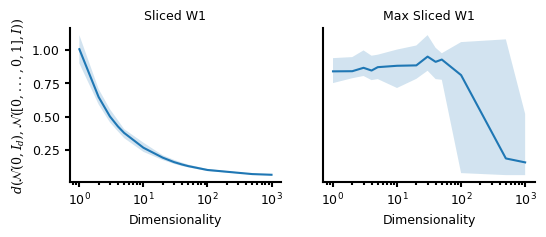

In [191]:
with use_style("pyloric"):
    fig, axes = plt.subplots(1,2,figsize=(6, 2))
    axes[0].set_title('Sliced W1')
    axes[1].set_title('Max Sliced W1')
    axes[0].plot(dims, sliced_w1_by_dimensionality_mean, label='Mean')
    axes[0].fill_between(dims, sliced_w1_by_dimensionality_q_01, sliced_w1_by_dimensionality_q_99, alpha=0.2, label='99% CI')
    axes[0].set_xscale('log')
    axes[0].set_xlabel('Dimensionality')
    axes[0].set_ylabel(r"$d(\mathcal{N}(0, I_d), \mathcal{N}([0,...,0,1], I))$")


    axes[1].plot(dims, max_sliced_w1_by_dimensionality_mean, label='Mean')
    axes[1].fill_between(dims, max_sliced_w1_by_dimensionality_q_01, max_sliced_w1_by_dimensionality_q_99, alpha=0.2, label='99% CI')
    axes[1].set_xscale('log')
    axes[1].set_yticks([])
    axes[1].set_xlabel('Dimensionality')
    fig.savefig('figures/wasserstein_dimensionality.png', dpi=300)

  

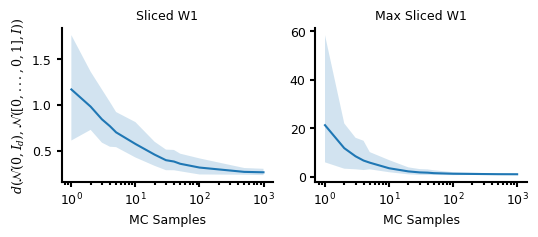

In [221]:
with use_style("pyloric"):
    fig, axes = plt.subplots(1,2,figsize=(6, 2))
    axes[0].set_title('Sliced W1')
    axes[1].set_title('Max Sliced W1')
    axes[0].plot(mc_samples, sliced_w1_by_mc_samples_mean, label='Mean')
    axes[0].fill_between(mc_samples, sliced_w1_by_mc_samples_q_01, sliced_w1_by_mc_samples_q_99, alpha=0.2, label='99% CI')
    axes[0].set_xscale('log')
    axes[0].set_xlabel('MC Samples')
    axes[0].set_ylabel(r"$d(\mathcal{N}(0, I_d), \mathcal{N}([0,...,0,1], I))$")


    axes[1].plot(mc_samples, max_sliced_w1_by_mc_samples_mean, label='Mean')
    axes[1].fill_between(mc_samples, max_sliced_w1_by_mc_samples_q_01, max_sliced_w1_by_mc_samples_q_99, alpha=0.2, label='99% CI')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('MC Samples')
    fig.savefig('figures/wasserstein_mc_samples.png', dpi=300)

  

In [85]:
distanc_matrix_by_num_slices = []
for s in [1, 10, 100,1000]:
    distances_sliced_w1 = jnp.zeros((len(distributions), len(distributions)))
    key = jax.random.PRNGKey(0)
    for i in range(len(distributions)):
        for j in range(i, len(distributions)):
            key, subkey = jax.random.split(key)
            distance_sliced_w1 = sliced_wasserstein_distance(distributions[i], distributions[j], mc_samples=5000, key=key,  num_slices=s)
            distances_sliced_w1 = distances_sliced_w1.at[i, j].set(distance_sliced_w1)
            
    # Normalize with self distance and symmetrize
    distances_sliced_w1 = distances_sliced_w1 - jnp.diag(distances_sliced_w1)[:, None]
    distances_sliced_w1 = jnp.triu(distances_sliced_w1) + jnp.triu(distances_sliced_w1, k=1).T
    distanc_matrix_by_num_slices.append(distances_sliced_w1)

In [91]:
distanc_matrix_by_mc_samples = []
for s in [10, 100,500,1000]:
    distances_sliced_w1 = jnp.zeros((len(distributions), len(distributions)))
    key = jax.random.PRNGKey(0)
    for i in range(len(distributions)):
        for j in range(i, len(distributions)):
            key, subkey = jax.random.split(key)
            distance_sliced_w1 = sliced_wasserstein_distance(distributions[i], distributions[j], mc_samples=5000, key=key,  num_slices=1000)
            distances_sliced_w1 = distances_sliced_w1.at[i, j].set(distance_sliced_w1)
            
    # Normalize with self distance and symmetrize
    distances_sliced_w1 = distances_sliced_w1 - jnp.diag(distances_sliced_w1)[:, None]
    distances_sliced_w1 = jnp.triu(distances_sliced_w1) + jnp.triu(distances_sliced_w1, k=1).T
    distanc_matrix_by_mc_samples.append(distances_sliced_w1)

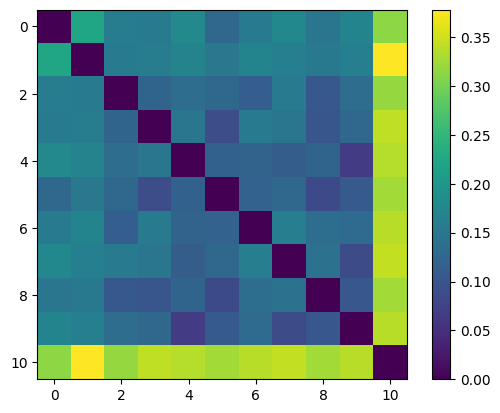

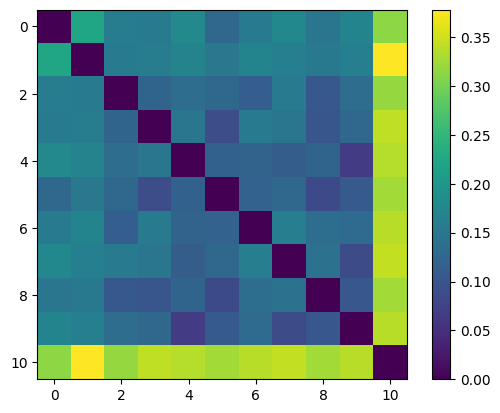

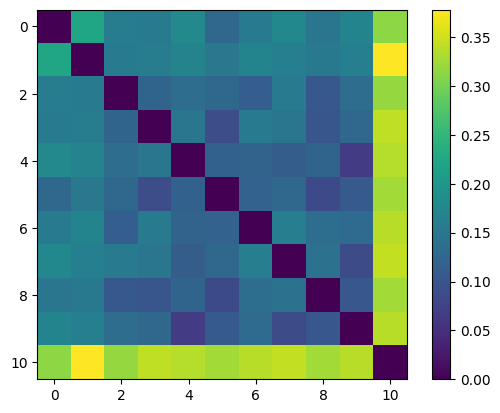

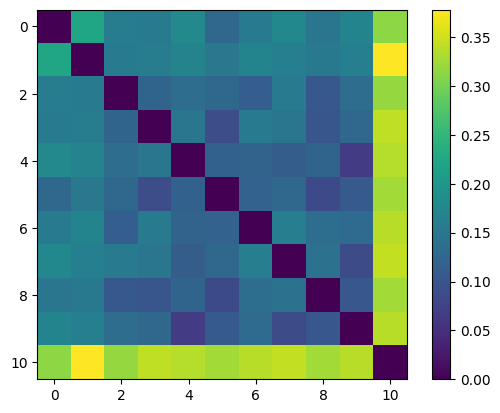

In [92]:
for i, d in enumerate(distanc_matrix_by_mc_samples):
    plt.imshow(d)
    plt.colorbar()
    plt.savefig(f'figures/distances_sliced_w1_{i}.png', dpi=300)
    plt.show()